In [16]:
import json
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, AutoTokenizer, get_scheduler
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from tqdm.notebook import tqdm, trange
from time import perf_counter
from PIL import Image
import pandas as pd
from PIL import Image
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

print("Done.")

Done.


In [17]:
# set random seeds for repeatability
import numpy as np
import random

def set_seed(seed_val):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

In [18]:
seed_val = 42
set_seed(seed_val)

In [19]:
pd.set_option('display.max_columns', None)

In [20]:
feat_array_classified = pd.read_pickle("./content/2024-08-19_feat_array_unscaled.pkl")

with open("./content/2024-08-18_curr_df.pkl", 'rb') as f:
  df_classes_classified = pickle.load(f) # deserialize using load()

df_classes_classified

,class,noise,path,seed,dir,pred_class,pc1,pc2
0,2,2,0.png,0,/content/Images3/,1,-31.683971,-14.198348
1,None,2,1.png,1,/content/Images3/,2,31.977729,-17.444531
2,2,2,2.png,2,/content/Images3/,1,-31.683971,-14.198348
3,None,2,3.png,3,/content/Images3/,2,31.347501,-16.048195
4,2,2,4.png,4,/content/Images3/,1,-31.683971,-14.198348
...,...,...,...,...,...,...,...,...
32205,2,4,noise 4 20872.0.png,20872.0,/content/Images1/,1,-31.683971,-14.198348
32206,1,4,noise 4 22801.0.png,22801.0,/content/Images1/,0,0.036469,36.126034
32207,2,5,noise 5 21620.0.png,21620.0,/content/Images1/,1,-31.683971,-14.198348
32208,2,3,noise 3 21522.0.png,21522.0,/content/Images1/,1,-31.683971,-14.198348


In [21]:
with open("./content/2024-08-19_feats_df_narrow.pkl", 'rb') as f:
  feats_df = pickle.load(f) # deserialize using load()

feats_df.shape

(33770, 111)

In [22]:
cols = list(feats_df.columns)
# for i in cols:
#   print(i)

feats_df[cols[0:20]].head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388
3,0.036364,0.055723,0.088968,0.107719,-0.126763,0.011323,0.809702,1,2,11.png,11,/content/Images3/,1,60,3.927,0,10.266667,2.064515,100.278917,58.248816
4,0.035847,0.078762,0.07823,0.101485,-0.115752,0.010542,0.933894,1,2,12.png,12,/content/Images3/,1,73,7.931,0,17.041096,3.365572,103.192973,59.580318


In [23]:
df_classes_classified.head()

,class,noise,path,seed,dir,pred_class,pc1,pc2
0,2,2,0.png,0,/content/Images3/,1,-31.683971,-14.198348
1,None,2,1.png,1,/content/Images3/,2,31.977729,-17.444531
2,2,2,2.png,2,/content/Images3/,1,-31.683971,-14.198348
3,None,2,3.png,3,/content/Images3/,2,31.347501,-16.048195
4,2,2,4.png,4,/content/Images3/,1,-31.683971,-14.198348


In [24]:
#add full path to each dataframe to allow matching based on unique path

fdf_full_path = []
for i in range(feats_df.shape[0]):
  fdf_full_path.append(feats_df["dir"][i] + feats_df["path"][i])


cdf_full_path = []
for j in range(df_classes_classified.shape[0]):
  cdf_full_path.append((df_classes_classified["dir"][j] + df_classes_classified["path"][j]))


feats_df["full_path"] = fdf_full_path
df_classes_classified["full_path"] = cdf_full_path

In [25]:
indices_1 = []
indices_2 = []
errors = 0
counter = 0
for i in range(df_classes_classified.shape[0]):
  #pull up path to search for
  path = df_classes_classified["full_path"][i]

  #find index within feats_df that matches path
  ind_df = feats_df[feats_df["full_path"] == path]

  if ind_df.shape[0] == 1:
    ind = ind_df.index[0]
    # print(ind_df.head())
    indices_1.append(ind)
    indices_2.append(i)
  else:
    # indices.append("error")
    # print("error")
    errors += 1


  if counter % 1000 == 0:
    print(counter)

  counter += 1




0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000


In [26]:
print(errors)

4695


In [27]:
# match dfs

feats_df = feats_df.iloc[indices_1]
df_classes_classified = df_classes_classified.iloc[indices_2]
feats_df.reset_index(inplace = True, drop = True)
df_classes_classified.reset_index(inplace = True, drop = True)

In [28]:
same = list(np.array(feats_df["full_path"]) == np.array(df_classes_classified["full_path"]))

print(same.count(True))
print(same.count(False))
print(len(same))

27515
0
27515


In [29]:
np.unique(np.array(df_classes_classified["pred_class"]))

array([0, 1, 2, 3, 4, 5, 6])

In [30]:
feats_df.head()

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,full_path
0,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3136.500000,649.910626,100.0,0.0,3136.500000,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,/content/Images3/1.png
1,0.034475,0.059956,0.080798,0.10037,-0.132577,0.008852,0.854084,1,2,3.png,3,/content/Images3/,1,63,4.921,0,12.253968,2.569468,101.800571,59.297600,99.451270,58.953924,11.663270,1.365051,99.968254,59.323693,97.619048,58.964458,3.666667,0.534522,3.666667,0.534522,4.237317,0.401713,3.661714,0.572434,56.049556,60.605082,0.999619,0.003000,4.908365,0.491745,3124.761905,655.214389,100.0,0.0,3124.761905,655.214389,100.158730,59.330446,98.079365,59.017431,120.191190,32.406426,3.476190,0.613529,1.185032,0.226780,0.867667,0.127976,0.954905,0.046408,1,250.078,255,39228.0,0.0,99.992,0.0,100.015,0.0,809.255,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.524,0.0,223.451,0.0,72.380,0.0,0.753,0.0,282.843,0.0,10003140.0,0.0,100.0,0.0,10003140.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.981,0.0,/content/Images3/3.png
2,0.028367,0.057912,0.073998,0.080784,-0.133789,0.008512,0.534244,1,2,7.png,7,/content/Images3/,1,77,4.692,0,9.558442,1.427863,100.557675,58.022388,98.103338,59.633687,10.379961,1.091819,98.870130,58.006796,96.519481,59.576560,3.402597,0.564300,3.194805,0.559196,3.806623,0.403173,3.196818,0.352550,29.220831,46.845042,0.992974,0.032896,4.416805,0.320359,2437.402597,364.105032,100.0,0.0,2437.402597,364.105032,98.961039,57.996292,96.753247,59.526521,133.450130,23.616781,2.961039,0.375951,1.209857,0.220792,0.849429,0.129524,0.946805,0.050966,1,250.308,255,39264.0,0.0,99.987,0.0,100.001,0.0,808.326,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.626,0.0,223.554,0.0,5.766,0.0,0.755,0.0,282.843,0.0,10012320.0,0.0,100.0,0.0,10012320.0,0.0,0.0,0.0,200.0,0.0,45.0,0.0,200.0,0.0,1.000,0.0,1.000,0.0,0.982,0.0,/content/Imag

In [31]:
# continue renaming and combining

feats_df["classifier_pred_class"] = df_classes_classified["pred_class"]
# feats_df["PC1_classifier_feats"] = df_classes_classified["PC1_classifier_feats"]
# feats_df["PC2_classifier_feats"] = df_classes_classified["PC2_classifier_feats"]

In [32]:
feats_df[feats_df.columns[13:111]].columns

Index(['num_spots', 'Mean', 'Median', 'Area_mean', 'Area_std', 'X_mean',
       'X_std', 'Y_mean', 'Y_std', 'Perim._mean', 'Perim._std', 'BX_mean',
       'BX_std', 'BY_mean', 'BY_std', 'Width_mean', 'Width_std', 'Height_mean',
       'Height_std', 'Major_mean', 'Major_std', 'Minor_mean', 'Minor_std',
       'Angle_mean', 'Angle_std', 'Circ._mean', 'Circ._std', 'Feret_mean',
       'Feret_std', 'IntDen_mean', 'IntDen_std', '%Area_mean', '%Area_std',
       'RawIntDen_mean', 'RawIntDen_std', 'FeretX_mean', 'FeretX_std',
       'FeretY_mean', 'FeretY_std', 'FeretAngle_mean', 'FeretAngle_std',
       'MinFeret_mean', 'MinFeret_std', 'AR_mean', 'AR_std', 'Round_mean',
       'Round_std', 'Solidity_mean', 'Solidity_std', 'num_spots_inverted',
       'Mean_inverted', 'Median_inverted', 'Area_inverted_mean',
       'Area_inverted_std', 'X_inverted_mean', 'X_inverted_std',
       'Y_inverted_mean', 'Y_inverted_std', 'Perim._inverted_mean',
       'Perim._inverted_std', 'BX_inverted_mean', 'BX_

In [33]:
# PCA on feat arrays

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


feat_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[13:111]]))


# feat_array_scaled = sc.fit_transform(feat_array_scaled)


print(feat_array_scaled.shape)


# Applying PCA function on training
# and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

pca_data = pca.fit_transform(feat_array_scaled)


explained_variance = pca.explained_variance_ratio_

print(explained_variance)

feats_df["pc1"] = pca_data[:,0]
feats_df["pc2"] = pca_data[:,1]


# PCA components (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=feat_array_scaled.columns)

print("PCA Loadings:")
print(loadings)

# Find top features for each principal component
top_features = {}
for pc in loadings.columns:
    top_features[pc] = loadings[pc].abs().nlargest(3).index.tolist()  # Top 3 contributing features
print("\nTop Contributing Features per Principal Component:")
print(top_features)


(27515, 98)
[0.40902343 0.25403697]
PCA Loadings:
         PC1       PC2
0   0.068897  0.144352
1  -0.017321 -0.115555
2  -0.018855 -0.135199
3  -0.114329 -0.136092
4   0.087364 -0.073967
..       ...       ...
93  0.094830 -0.088012
94 -0.122099  0.104895
95  0.124236 -0.112134
96 -0.100552 -0.072378
97  0.123014 -0.088315

[98 rows x 2 columns]

Top Contributing Features per Principal Component:
{'PC1': [26, 45, 52], 'PC2': [25, 9, 58]}


In [34]:
# rearrange and combine dataframes

# df_classes_classified["PC1_classifier_feats"] = df_classes_classified["pc1"]
# df_classes_classified["PC2_classifier_feats"] = df_classes_classified["pc2"]
# df_classes_classified = df_classes_classified.drop(["class","pc1","pc2"], axis = "columns")

KeyError: 'pc1_imagej_features'

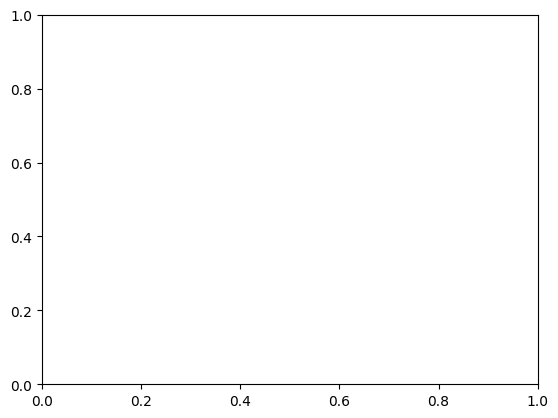

In [35]:
# plot the model predicted class in feature space


num_classes = 6
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)


feat_1 = "pc1_imagej_features"

feat_2 = "pc2_imagej_features"

fig, ax = plt.subplots()

colors = ["red","green","blue","purple","orange","black","pink"]
alpha = [1,1,1,1,1,1,1]
for j in classes:
  df = class_dfs[j]
  ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


leg = ax.legend(loc="upper left")

ax.set(xlabel = "PC1 (0.41)", ylabel = "PC2 (0.25)", title = "")
plt.show()



In [ ]:
df = class_dfs[4]

for i in range(df.shape[0]):
  print("(" + str(df[ "pc1_imagej_features"][i]) + "," + str(df[ "pc2_imagej_features"][i]) +  "," + str(df["pc3_imagej_features"][i]) + "),")

In [ ]:
# do clusters in first 3 PCs

from mpl_toolkits import mplot3d


num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)


feat_1 = "pc1_imagej_features"

feat_2 = "pc2_imagej_features"

feat_3 = "pc3_imagej_features"

for k in range(10):
  # Creating 3D figure
  fig = plt.figure(figsize=(8, 8))
  ax = plt.axes(projection='3d')

  colors = ["red","green","blue","purple","orange","black","pink"]
  alpha = [1,1,1,1,1,1,0]
  for j in classes:
    df = class_dfs[j]
    ax.scatter3D(df[feat_1], df[feat_2], df[feat_3], c = colors[j], label = "class " + str(j), alpha = alpha[j])


  leg = ax.legend(loc="upper left")

  ax.set(xlabel = feat_1, ylabel = feat_2, zlabel = feat_3)

  # 360 Degree view
  ax.view_init(0, 36*k)


  plt.show()

Exploration of combos of points in 2D and 3D

In [ ]:
# plot the model predicted class in feature space

def plotter(feat_1,feat_2):
  num_classes = 7
  classes = np.arange(0,num_classes)# list of unique clusters

  class_dfs = [] # list of dfs for each cluster

  for i in classes:
    df = feats_df[feats_df["classifier_pred_class"] == i]
    df.reset_index(inplace = True, drop = True)
    class_dfs.append(df)

  fig, ax = plt.subplots()

  colors = ["red","green","blue","purple","orange","black","pink"]
  alpha = [1,0,0,0,0,0,0]
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


  leg = ax.legend(loc="upper left")

  ax.set(xlabel = feat_1, ylabel = feat_2)
  plt.show()

  return

params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]

for p1 in params:
  for p2 in params:
    if p1 != p2:
      plotter(p1,p2)

In [ ]:
# make all of the params type float

feats_df[["Ua","Ui","Ga","Gi","Da","Di","Ba"]] = feats_df[["Ua","Ui","Ga","Gi","Da","Di","Ba"]].astype(float)

In [ ]:
# do clusters in first 3 PCs

from mpl_toolkits import mplot3d

def threeD_plotter(feat_1,feat_2,feat_3):
    num_classes = 7
    classes = np.arange(0,num_classes)# list of unique clusters

    class_dfs = [] # list of dfs for each cluster

    for i in classes:
      df = feats_df[feats_df["classifier_pred_class"] == i]
      df.reset_index(inplace = True, drop = True)
      class_dfs.append(df)


    # feat_1 = "pc1_imagej_features"

    # feat_2 = "pc2_imagej_features"

    # feat_3 = "pc3_imagej_features"

    # for k in range(10):
    # Creating 3D figure
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection='3d')

    colors = ["red","green","blue","purple","orange","black","pink"]
    alpha = [1,1,1,1,1,1,0]
    for j in classes:
      df = class_dfs[j]
      ax.scatter3D(df[feat_1], df[feat_2], df[feat_3], c = colors[j], label = "class " + str(j), alpha = alpha[j])


    leg = ax.legend(loc="upper left")

    ax.set(xlabel = feat_1, ylabel = feat_2, zlabel = feat_3)

    # 360 Degree view
    ax.view_init(30, 90)
    plt.show()


params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]

for i in range(len(params)):
  for j in range(i,len(params)):
    for k in range(j,len(params)):
      if i != j and j != k:
        threeD_plotter(params[i],params[j],params[k])

In [ ]:
# plot ratios of params

def ratio_plotter(feat_1,feat_2):
  num_classes = 7
  classes = np.arange(0,num_classes)# list of unique clusters

  class_dfs = [] # list of dfs for each cluster

  for i in classes:
    df = feats_df[feats_df["classifier_pred_class"] == i]
    df.reset_index(inplace = True, drop = True)
    class_dfs.append(df)

  fig, ax = plt.subplots()

  colors = ["red","green","blue","purple","orange","black","pink"]
  alpha = [1,1,1,1,1,1,0]
  for j in classes:
    df = class_dfs[j]
    ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


  leg = ax.legend(loc="upper left")

  ax.set(xlabel = feat_1, ylabel = feat_2)
  plt.show()

  return


params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]
counter = 0
for i in range(len(params)):
  for j in range(i,len(params)):
    for k in range(len(params)):
      for l in range(k,len(params)):
        p0 = params[i]
        p1 = params[j]
        p2 = params[k]
        p3 = params[l]

        if p0 != p1 and p1 != p2 and p2 != p3 and p1 != p3 and p0 != p3:
          ratio_1 = np.array(feats_df[p0]) / np.array(feats_df[p1])
          feats_df[p0 + "/" + p1] = ratio_1

          ratio_2 = np.array(feats_df[p2]) / np.array(feats_df[p3])
          feats_df[p2 + "/" + p3] = ratio_2
          if plot:
            ratio_plotter(p0 + "/" + p1, p2 + "/" + p3)
          counter += 1
print(counter)

In [ ]:
feats[0:28]

In [ ]:
feats_df.columns[116:137]

In [ ]:
feats = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba']  + list(feats_df.columns[13:111])

feats_extra = []

for i in feats:
  feats_extra.append(i + " mean")
  feats_extra.append(i + " min")
  feats_extra.append(i + " max")
  feats_extra.append(i + " std")

feats = feats_extra
print(len(feats))

num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster
rows = {}

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)
  rows[str(i)] = []


for i in range(num_classes):
  df = class_dfs[i]
  for j in range(0,len(feats),4):
    mean_val = np.mean(np.array(df[feats[j][0:feats[j].index(" ")]].astype(float)))
    rows[str(i)].append(mean_val)

    min_val = np.min(np.array(df[feats[j][0:feats[j].index(" ")]].astype(float)))
    rows[str(i)].append(min_val)

    max_val = np.max(np.array(df[feats[j][0:feats[j].index(" ")]].astype(float)))
    rows[str(i)].append(max_val)

    std = np.std(np.array(df[feats[j][0:feats[j].index(" ")]].astype(float)))
    rows[str(i)].append(std)

    # print("Cluster " + str(i) + " avg " + feat + ": " + str(mean_val))

In [ ]:
cluster_means_df = pd.DataFrame(rows)
# cluster_means_df["feats"] = feats
cluster_means_df = cluster_means_df.transpose()
cluster_means_df.columns = feats

cluster_means_df

In [ ]:
# print bar plots for each param based on class

feats = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba'] + list(feats_df.columns[13:111])

num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster
rows = {}

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)
  rows[str(i)] = []

colors = ["red","green","blue","purple","orange","turquoise","pink"]

for i in range(len(feats)):
  param = feats[i]
  print(param)
  param_list = cluster_means_df.columns
  means = cluster_means_df[param_list[i*4]]
  print(list(means))
  mins = cluster_means_df[param_list[(i*4) + 1]]
  print(list(mins))
  maxes = cluster_means_df[param_list[(i*4) + 2]]
  print(list(maxes))
  stds = cluster_means_df[param_list[(i*4) + 3]]
  print(list(stds))

  # bar plots
  fig, ax = plt.subplots()
  ax.bar(["0","1","2","3","4","5","6"], means, width = 0.3, color = colors[i%6], yerr = stds)



  #set min and max points
  ax.scatter(classes, mins, color = "black")
  ax.scatter(classes, maxes, color = "black")



  ax.set(title = "Mean " + param)

  plt.show()







In [ ]:
feats_df.columns[-10:]

In [ ]:
print(feats_df["Ua"])
print(feats_df["Ua_scaled"])

In [ ]:
# scale each param so we can plot them next to each other
params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]
params_df = feats_df[params]

from sklearn.preprocessing import MinMaxScaler


for param in  params:
  sc = MinMaxScaler()
  param_arr = np.array(params_df[param]).reshape(-1,1)
  param_arr_scaled = sc.fit_transform(param_arr)
  feats_df[param + "_scaled"] = param_arr_scaled


feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']

feats_extra = []

for i in feats:
  feats_extra.append(i + " mean")
  feats_extra.append(i + " min")
  feats_extra.append(i + " max")
  feats_extra.append(i + " std")

feats = feats_extra
print(len(feats))

num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster
rows = {}

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)
  rows[str(i)] = []


for i in range(num_classes):
  df = class_dfs[i]
  for j in range(0,len(feats),4):
    mean_val = np.mean(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(mean_val)

    min_val = np.min(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(min_val)

    max_val = np.max(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(max_val)

    std = np.std(np.array(df[feats[j][0:9]].astype(float)))
    rows[str(i)].append(std)

    # print("Cluster " + str(i) + " avg " + feat + ": " + str(mean_val))


cluster_means_df = pd.DataFrame(rows)
# cluster_means_df["feats"] = feats
cluster_means_df = cluster_means_df.transpose()
cluster_means_df.columns = feats

cluster_means_df


In [ ]:
# Do all 7 main params on the same plot

# print bar plots for each param based on class

feats = ['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled']
num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)

colors = ["red","green","blue","purple","orange","turquoise","pink"]
fig, ax = plt.subplots(figsize = (12,8))
for i in range(len(feats)):
  param = feats[i]
  print(param)
  param_list = cluster_means_df.columns
  means = cluster_means_df[param_list[i*4]]
  print(list(means))
  mins = cluster_means_df[param_list[(i*4) + 1]]
  print(list(mins))
  maxes = cluster_means_df[param_list[(i*4) + 2]]
  print(list(maxes))
  stds = cluster_means_df[param_list[(i*4) + 3]]
  print(list(stds))

  # bar plots
  width = 0.32
  # fig, ax = plt.subplots()
  bar_pos = (np.array([0,3,6,9,12,15,18]) + width*i )
  ax.bar(bar_pos, means, width = width, color = colors[i%6], yerr = stds)



  #set min and max points
  ax.scatter(bar_pos, mins, color = "black")
  ax.scatter(bar_pos, maxes, color = "black")



ax.set(title = "Mean Params By Classes")

leg = ax.legend(['Ua_scaled', 'Ui_scaled', 'Ga_scaled',
        'Gi_scaled', 'Da_scaled', 'Di_scaled', 'Ba_scaled'], loc="upper left")
leg = ax.get_legend()
leg.legendHandles[0].set_color('red')
leg.legendHandles[1].set_color('green')
leg.legendHandles[2].set_color('blue')
leg.legendHandles[3].set_color('purple')
leg.legendHandles[4].set_color('orange')
leg.legendHandles[5].set_color('turquoise')
leg.legendHandles[6].set_color('pink')



ax.set_xticks([1,4,7,10,13,16,19])
ax.set_xticklabels(["0",'1', '2', '3', '4', '5', "6"])


plt.show()







In [ ]:
feats_df.columns[13:112]

In [ ]:
from sklearn.linear_model import LinearRegression

feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)

lin_reg=LinearRegression()
lin_reg.fit(feat_1,param_1)

In [ ]:
from sklearn.linear_model import LinearRegression

#initiate linear regression model
model = LinearRegression()

#define predictor and response variables
feat_1 = np.array(feats_df["num_spots"]).reshape(-1,1)
param_1 = np.array(feats_df["Ua"]).reshape(-1,1)

#fit regression model
model.fit(param_1, feat_1)

#calculate R-squared of regression model
r_squared = model.score(param_1, feat_1)

#view R-squared value
print(r_squared)


In [ ]:
from sklearn.linear_model import LinearRegression

params = ["Ua","Ui","Ga","Gi","Da","Di","Ba",'Ua/Ui', 'Ua/Ga', 'Ua/Gi', 'Ua/Da', 'Ua/Di', 'Ua/Ba', 'Ga/Gi', 'Ga/Da',
       'Ga/Di', 'Ga/Ba', 'Gi/Da', 'Gi/Di', 'Gi/Ba', 'Da/Di', 'Da/Ba', 'Di/Ba',
       'Ui/Gi', 'Ui/Da', 'Ui/Di', 'Ui/Ba']
feats = list(feats_df.columns[13:111])


p_list = []
f_list = []
r2 = []

for param in params:
  for feat in feats:
    model = LinearRegression()

    #define predictor and response variables
    feat_1 = np.array(feats_df[feat]).reshape(-1,1)
    param_1 = np.array(feats_df[param]).reshape(-1,1)

    #fit regression model
    model.fit(param_1, feat_1)

    #calculate R-squared of regression model
    r_squared = model.score(param_1, feat_1)

    r2.append(r_squared)
    p_list.append(param)
    f_list.append(feat)

r2_dic = {"feat": f_list,"param":p_list,"r2":r2}

r2_df = pd.DataFrame(r2_dic)

In [ ]:
r2_sorted = r2_df.sort_values(by=['r2'], ascending = False)

r2_sorted[r2_sorted["feat"] == "Mean"]

In [ ]:
# plot the model predicted class in feature space


num_classes = 7
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

for i in classes:
  df = feats_df[feats_df["classifier_pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)


feat_1 = "Mean"

feat_2 = "Ui"

fig, ax = plt.subplots()

colors = ["red","green","blue","purple","orange","black","pink"]
alpha = [1,1,1,1,1,1,0]
for j in classes:
  df = class_dfs[j]
  ax.scatter(df[feat_1], df[feat_2], c = colors[j], label = "class " + str(j), alpha = alpha[j])


leg = ax.legend(loc="upper left")

ax.set(xlabel = feat_1, ylabel = feat_2)
plt.show()


In [ ]:
# isolate individual param scans for comparison accross feature space

with open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-012_imagej_feats_inverted_no_dfs_df.pkl", 'rb') as f:
  feats_df = pickle.load(f) # deserialize using load()


In [ ]:
feats_df.reset_index(inplace = True, drop = True)

In [ ]:
feats_df[["Ua","Ui"]].iloc[0]

In [ ]:
feats_df.head()

In [ ]:
params = ["Ua","Ui","Ga","Gi","Da","Ba"]


prog = 0
ind_list = []
for i in range(0,feats_df.shape[0]-1):
  curr = np.array(feats_df[params].iloc[i])
  next = np.array(feats_df[params].iloc[i+1])
  if (curr == next).all():
    ind_list.append(i)

  if prog % 500 == 0:
    print(prog)
  prog += 1





In [ ]:
# ua_only_scan = feats_df.iloc[ind_list[540:-3]]
# ua_only_scan.reset_index(inplace = True, drop = True)
# ui_only_scan = feats_df.iloc[ind_list[1081:-3]]
# ui_only_scan.reset_index(inplace = True, drop = True)
# ga_only_scan = feats_df.iloc[ind_list[54:-3]]
# ga_only_scan.reset_index(inplace = True, drop = True)
# gi_only_scan = feats_df.iloc[ind_list[216:-3]]
# gi_only_scan.reset_index(inplace = True, drop = True)
# da_only_scan = feats_df.iloc[ind_list[0:-3]]
# da_only_scan.reset_index(inplace = True, drop = True)
# di_only_scan = feats_df.iloc[ind_list[0:299]]
# di_only_scan.reset_index(inplace = True, drop = True)

# ba_only_scan = feats_df.iloc[ind_list[0:-3]]
# ba_only_scan.reset_index(inplace = True, drop = True)
# single_param_dic = {"Ua":ua_only_scan,"Ui":ui_only_scan,"Ga":ga_only_scan,"Gi":gi_only_scan,"Da":da_only_scan,"Di":di_only_scan,"Ba":ba_only_scan}

In [ ]:
# save single param dfs


# pickle_out = open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-28_single_param_scans.pkl","wb")
# pickle.dump(single_param_dic, pickle_out)
# pickle_out.close()

In [ ]:
# load in the single param dfs

with open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-28_single_param_scans.pkl", 'rb') as f:
  single_dic = pickle.load(f) # deserialize using load()

with open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-30_imagej_feats_inverted_no_dfs_df.pkl", 'rb') as f:
  feats_df = pickle.load(f) # deserialize using load()


In [ ]:
single_dic["Ua"].head()

In [ ]:
feats_df.head()

In [ ]:
# create a new dictionary containing the classes by searching

indices = {"Ua":[],"Ui":[],"Ga":[],"Gi":[],"Da":[],"Di":[],"Ba":[]}


for i in single_dic.keys():
  print(i)
  df = single_dic[i]
  df.reset_index(inplace = True, drop = True)
  for j in range(df.shape[0]):
    path = df["dir"][j] + df["path"][j]
    line = feats_df[feats_df["full_path"] == path]
    indices[i].append(line.index[0])



single_classes = {"Ua":None,"Ui":None,"Ga":None,"Gi":None,"Da":None,"Di":None,"Ba":None}

for i in indices.keys():
  ind_list = indices[i]
  df = feats_df.iloc[ind_list]
  df.reset_index(inplace = True, drop = True)
  single_classes[i] = df



In [ ]:
feats_df.columns[13:-3]

In [ ]:
single_classes["Ua"].head()

In [ ]:
#sort all the dfs
for i in single_classes.keys():
  df = single_classes[i]
  df[["Ua","Ui","Ga","Gi","Da","Di","Ba"]] = df[["Ua","Ui","Ga","Gi","Da","Di","Ba"]].astype(float)
  df = df.sort_values(by = i)
  single_classes[i] = df


# print out random images from clusters

num_imgs = 299


for i in range(num_imgs):
  fig, ax = plt.subplots(1,7)
  for j in range(7):
    params = ["Ua","Ui","Ga","Gi","Da","Di","Ba"]
    df = single_classes[params[j]]
    try:
      img = np.array(Image.open(df["dir"][i] + df["path"][i]))
      ax[j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
      ax[j].set_title(str(params[j]) + " = "+ str(df[params[j]][i]), fontsize = 8)
      ax[j].get_xaxis().set_visible(False)
      ax[j].get_yaxis().set_visible(False)
    except:
      img = np.zeros([200,200])
      ax[j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
      ax[j].set_title(str("End of param"), fontsize = 8)
      ax[j].get_xaxis().set_visible(False)
      ax[j].get_yaxis().set_visible(False)
  fig.set_figwidth(5*7)
  fig.set_figheight(5)
  plt.show()

In [ ]:
#plot every image in all the dfs

In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "num_spots"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["pred_class"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Mean"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["pred_class"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Circ._mean"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["pred_class"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Area_mean"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["pred_class"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Area_mean"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["pred_class"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Area_std"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["pred_class"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()


In [ ]:
# plot some dependencies

keys = list(single_classes.keys())
# feat_1 = "Ua"
feat_2 = "Perim._mean"

colors = ["red","green","blue","purple","orange","black","pink"]

# iterate through params
for i in range(7):
  fig, ax = plt.subplots()
  # iterate through classes
  for j in range(6):

    # pull up the dataframe for the specific class
    df = single_classes[keys[i]]
    df = df[df["pred_class"] == j]
    df.reset_index(inplace = True, drop = True)


    x = df[keys[i]].astype(float)
    y = df[feat_2].astype(float)

    ax.scatter(x,y, color = colors[j])
  ax.legend([0,1,2,3,4,5,6])
  ax.set(title = keys[i], xlabel = keys[i], ylabel = feat_2)
  plt.show()
